  Self-consistent Poisson-NEGF (dolfinx) on 1D n-i-n chain
  N_sites = 40, t = 1.0 eV, V_DS = 0.0 V
  per-site doping (S/D) = 0.333, mu_ref = -1.00 eV
  alpha_poisson = 6.959e+00

[1] Pure Gummel ...
   Gummel finished in 300 iter, final |dphi|=2.56e-04

[2] Newton with FD Jacobian ...
   Newton-FD   1: |dphi|_max = 9.324e+00
   Newton-FD   2: |dphi|_max = 9.882e-01
   Newton-FD   3: |dphi|_max = 6.759e-02
   Newton-FD   4: |dphi|_max = 3.559e-03
   Newton-FD   5: |dphi|_max = 1.632e-04
   Newton-FD   6: |dphi|_max = 6.978e-06

[3] Newton with analytical (Ahn-Hong) Jacobian ...
   Newton-AN   1: |dphi|_max = 9.665e+00
   Newton-AN   2: |dphi|_max = 6.887e-01
   Newton-AN   3: |dphi|_max = 4.432e-02
   Newton-AN   4: |dphi|_max = 2.473e-03
   Newton-AN   5: |dphi|_max = 1.272e-04
   Newton-AN   6: |dphi|_max = 6.101e-06

Saved plot to coupled_negf_poisson_dolfinx.png

  Iterations to 1e-04: Gummel=300, Newton-FD=6, Newton-AN=6
  NEGF sweeps    : Gummel=300, Newton-FD=12, Newton-AN=6
  F

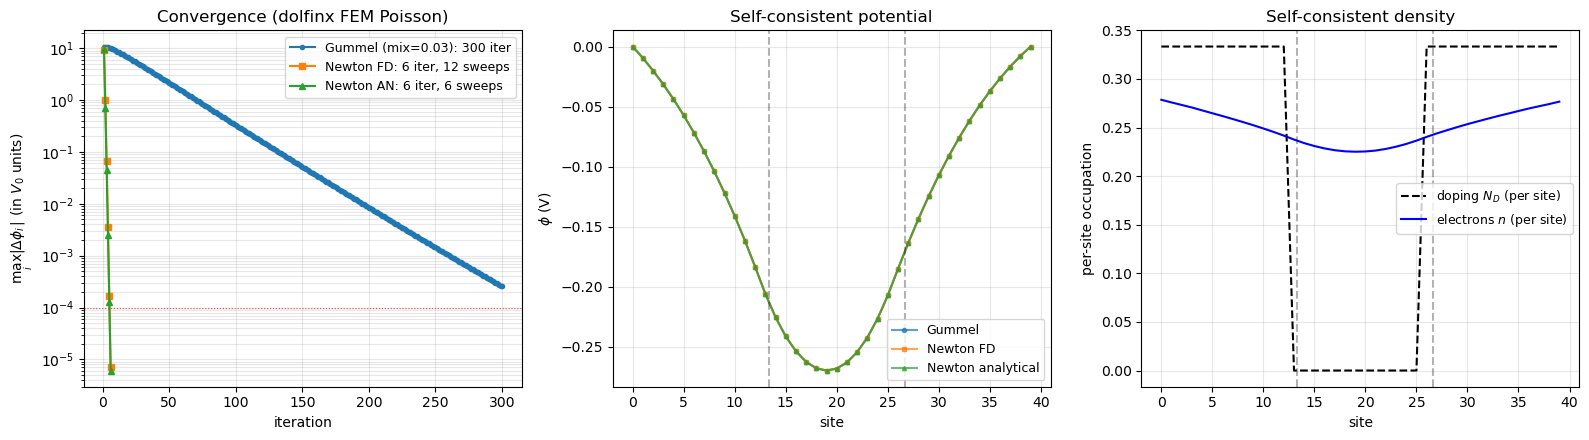

In [2]:
"""
Self-consistent Poisson-NEGF on a 1D tight-binding n-i-n chain — dolfinx.

Same physics as poisson_negf_coupled.py but the Poisson side is solved with
the FEM machinery (dolfinx + PETSc) instead of finite differences, so the
pattern matches what you have in your 3D nanowire code.

What translates 1:1 to the 3D code
----------------------------------
  * Bilinear form for the Newton step:
        a(du, v) = eps_r * inner(grad(du), grad(v)) * dx
                 + alpha_poisson * J * du * v * dx
    The second term is a *J-weighted mass matrix*.  J is the diagonal
    Ahn-Hong Jacobian dn/dphi; it lives on the same FEM function space
    as n and phi (so it inherits whatever atom->FEM translator you use
    for the charge density).

  * Linear residual:
        F(v) = eps_r * inner(grad(phi), grad(v)) * dx
             - alpha_poisson * (Nd - n) * v * dx
    Solve  a(du, v) = -F(v)  with  du = 0  on the Dirichlet boundary.

  * The NEGF side returns *both* n and J in a single energy sweep — see
    negf_density_and_jacobian().  J = -(V0/pi) * Re(G^R_ii) * Im(G^<_ii)
    integrated over E.  This is the only NEGF change from your existing
    code; everything else (Sigma, RGF kernel, energy grid) is unchanged.

Run
---
    python poisson_negf_coupled_dolfinx.py

Requires: dolfinx 0.7+, petsc4py, numpy, matplotlib.
"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from mpi4py import MPI
import ufl
from dolfinx import fem, mesh
from dolfinx.fem.petsc import LinearProblem
from petsc4py import PETSc


# --------------------------------------------------------------------- #
#  Physical constants and scaling                                       #
# --------------------------------------------------------------------- #
q     = 1.602e-19                # C
eps0  = 8.854e-12                # F/m
kT    = 0.026                    # eV at T = 300 K
V0    = kT                       # voltage scale
L0    = 5e-10                    # 5 A site spacing
eps_r = 11.7                     # silicon-like

# Effective wire cross-section in atomic units (only enters alpha).
N_cross       = 200.0
alpha_poisson = q / (eps0 * N_cross * L0 * V0)


# --------------------------------------------------------------------- #
#  Tight-binding device                                                 #
# --------------------------------------------------------------------- #
N_sites = 40
t_hop   = 1.0                    # eV
H0      = -t_hop * (np.eye(N_sites, k=1) + np.eye(N_sites, k=-1))

mu_ref          = -1.0           # eV
Nd_site         = (1.0 / np.pi) * (np.arcsin(mu_ref / (2.0 * t_hop)) + 0.5 * np.pi)
V_applied_left  = 0.0
V_applied_right = 0.0


# --------------------------------------------------------------------- #
#  Lead self-energy (analytical, semi-infinite 1D chain)                #
# --------------------------------------------------------------------- #
def sigma_lead_1d(E: float, t: float, eta: float = 5e-3) -> complex:
    z  = E + 1j * eta
    sq = np.sqrt(z * z - 4.0 * t * t)
    if sq.imag < 0:                    # want Im(g_s) < 0  (retarded)
        sq = -sq
    g = (z - sq) / (2.0 * t * t)
    return (t * t) * g


def lead_self_energies(E: float, eta: float = 5e-3):
    """Retarded self-energy with biased leads.  Lead band shifts with
    V_applied, so evaluate the unshifted lead at energy (E + V_applied).
    """
    sigL = np.zeros((N_sites, N_sites), dtype=complex)
    sigR = np.zeros((N_sites, N_sites), dtype=complex)
    sigL[0, 0]   = sigma_lead_1d(E + V_applied_left,  t_hop, eta)
    sigR[-1, -1] = sigma_lead_1d(E + V_applied_right, t_hop, eta)
    return sigL, sigR


# --------------------------------------------------------------------- #
#  NEGF density + analytical Jacobian, in one energy sweep              #
# --------------------------------------------------------------------- #
def negf_density_and_jacobian(
    phi_site: np.ndarray,
    mu_L: float,
    mu_R: float,
    E_grid: np.ndarray,
    eta: float = 5e-3,
    return_jacobian: bool = True,
):
    """
    phi_site has length N_sites and is in V0 units.
    H_eff = H0 - V0 * diag(phi_site).

    Returns
    -------
    n        : per-site occupation, length N_sites
    J_diag   : per-site dn/dphi, length N_sites  (when return_jacobian=True)
    """
    H_eff = H0 - V0 * np.diag(phi_site)
    n     = np.zeros(N_sites)
    J     = np.zeros(N_sites) if return_jacobian else None

    dE = np.gradient(E_grid)
    I_N = np.eye(N_sites, dtype=complex)

    for k, E in enumerate(E_grid):
        sigL, sigR = lead_self_energies(E, eta)

        z   = E + 1j * eta
        M   = z * np.eye(N_sites) - H_eff - sigL - sigR
        G_R = np.linalg.solve(M, I_N)
        G_A = G_R.conj().T

        Gamma_L = 1j * (sigL - sigL.conj().T)
        Gamma_R = 1j * (sigR - sigR.conj().T)

        fL = 1.0 / (1.0 + np.exp(np.clip((E - mu_L) / kT, -200, 200)))
        fR = 1.0 / (1.0 + np.exp(np.clip((E - mu_R) / kT, -200, 200)))
        Sigma_lesser = 1j * (fL * Gamma_L + fR * Gamma_R)
        G_lesser = G_R @ Sigma_lesser @ G_A

        diag_GR    = np.diag(G_R)
        diag_Gless = np.diag(G_lesser)

        n_E = (-1j * diag_Gless).real / (2.0 * np.pi)
        n  += n_E * dE[k]

        if return_jacobian:
            # ---- Ahn-Hong analytical Jacobian, diagonal block --------
            # dn_i/dphi_i = -(V0/pi) * Re(G^R_ii) * Im(G^<_ii)
            J_E = -(V0 / np.pi) * (diag_GR.real * diag_Gless.imag)
            J  += J_E * dE[k]

    return (n, J) if return_jacobian else n


# --------------------------------------------------------------------- #
#  FEM setup: 1D mesh, P1 space, BCs, dof <-> site mapping              #
# --------------------------------------------------------------------- #
domain = mesh.create_interval(MPI.COMM_WORLD, N_sites - 1,
                              [0.0, float(N_sites - 1)])
V = fem.functionspace(domain, ("Lagrange", 1))

# In 1D this serial mesh has N_sites dofs and N_sites-1 cells, exactly one
# dof per "atomic site" but the dof ordering is not the spatial ordering.
# We need both directions of mapping so the NEGF (site-indexed) and the
# FEM (dof-indexed) sides can hand data back and forth.
dof_x       = V.tabulate_dof_coordinates()[:, 0]    # x-coord of each dof
site_to_dof = np.argsort(dof_x).astype(np.int32)    # site k -> dof index
dof_to_site = np.argsort(site_to_dof).astype(np.int32)


def site_array_to_dof(arr_site: np.ndarray) -> np.ndarray:
    """Reorder a site-indexed array (len N_sites) to dof order."""
    out = np.empty_like(arr_site)
    out[site_to_dof] = arr_site
    return out


def dof_array_to_site(arr_dof: np.ndarray) -> np.ndarray:
    """Reorder a dof-indexed array to site order."""
    out = np.empty_like(arr_dof)
    out[dof_to_site] = arr_dof
    return out


# Field functions
phi   = fem.Function(V, name="phi")
n_fn  = fem.Function(V, name="n")
J_fn  = fem.Function(V, name="J")
Nd_fn = fem.Function(V, name="Nd")

# Donor profile (n-i-n)
Nd_site_arr = np.zeros(N_sites)
Nd_site_arr[: N_sites // 3]      = Nd_site
Nd_site_arr[2 * N_sites // 3 :]  = Nd_site
Nd_fn.x.array[:] = site_array_to_dof(Nd_site_arr)

# Initial phi: zero in interior; BC values applied below via dirichletbc
phi.x.array[:] = 0.0

# Dirichlet BCs (left = V_L/V0, right = V_R/V0)
def left_marker(x):  return np.isclose(x[0], 0.0)
def right_marker(x): return np.isclose(x[0], float(N_sites - 1))

left_dofs  = fem.locate_dofs_geometrical(V, left_marker)
right_dofs = fem.locate_dofs_geometrical(V, right_marker)

bc_left  = fem.dirichletbc(PETSc.ScalarType(V_applied_left  / V0),
                           left_dofs,  V)
bc_right = fem.dirichletbc(PETSc.ScalarType(V_applied_right / V0),
                           right_dofs, V)
bcs = [bc_left, bc_right]

# Apply BCs to the initial phi so the residual is consistent
fem.set_bc(phi.x.array, bcs)


# --------------------------------------------------------------------- #
#  Forms                                                                #
# --------------------------------------------------------------------- #
# Linearised Poisson around phi_old:
#     (A + alpha * J) * phi_new = alpha * (Nd - n + J * phi_old)
# where  J = dn/dphi  is positive.  Note: this matches your existing code
# verbatim if we identify your `-poisson_coeff * drho_dphi * u * v * dx`
# with the term `+ alpha * J * u * v * dx` (your drho_dphi is negative
# of dn/dphi, hence the minus sign in your bilinear form).
u, v = ufl.TrialFunction(V), ufl.TestFunction(V)

a_newton_ufl = (eps_r * ufl.inner(ufl.grad(u), ufl.grad(v))
                + alpha_poisson * J_fn * u * v) * ufl.dx
L_newton_ufl = (alpha_poisson * (Nd_fn - n_fn + J_fn * phi) * v) * ufl.dx

# Pure-Poisson forms for Gummel (no Jacobian term)
a_gummel_ufl = eps_r * ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
L_gummel_ufl = alpha_poisson * (Nd_fn - n_fn) * v * ufl.dx

# Solve writes directly into these (= phi_new at iteration end, not increment)
phi_candidate_newton = fem.Function(V, name="phi_candidate_newton")
phi_candidate_gummel = fem.Function(V, name="phi_candidate_gummel")

ksp_opts = {"ksp_type": "preonly", "pc_type": "lu"}

newton_problem = LinearProblem(
    a_newton_ufl, L_newton_ufl,
    u=phi_candidate_newton, bcs=bcs,
    petsc_options=ksp_opts,
    petsc_options_prefix="negf_newton_",
)
gummel_problem = LinearProblem(
    a_gummel_ufl, L_gummel_ufl,
    u=phi_candidate_gummel, bcs=bcs,
    petsc_options=ksp_opts,
    petsc_options_prefix="negf_gummel_",
)


# --------------------------------------------------------------------- #
#  Solver 1: pure Gummel                                                #
# --------------------------------------------------------------------- #
def solve_gummel(E_grid, max_iter=300, tol=1e-4, mix=0.05, verbose=False):
    """Linear-Poisson + NEGF + simple-mixing on phi."""
    phi.x.array[:] = 0.0
    fem.set_bc(phi.x.array, bcs)
    mu_L = mu_ref - V_applied_left
    mu_R = mu_ref - V_applied_right

    history = []
    for it in range(max_iter):
        n_site = negf_density_and_jacobian(
            dof_array_to_site(phi.x.array), mu_L, mu_R, E_grid,
            return_jacobian=False)
        n_fn.x.array[:] = site_array_to_dof(n_site)

        gummel_problem.solve()       # writes phi_candidate_gummel

        delta = phi_candidate_gummel.x.array - phi.x.array
        err   = float(np.max(np.abs(delta)))
        history.append(err)
        phi.x.array[:] = phi.x.array + mix * delta
        if verbose:
            print(f"   Gummel  {it+1:3d}: |dphi|_max = {err:.3e}")
        if err < tol:
            break

    return phi.x.array.copy(), history


# --------------------------------------------------------------------- #
#  Solver 2: Newton with finite-difference Jacobian                     #
# --------------------------------------------------------------------- #
def solve_newton_fd(E_grid, max_iter=40, tol=1e-4, fd_step=0.1,
                    mix=1.0, verbose=True):
    """Solve linearised Poisson for new phi directly (matches your 3D code).

    mix=1.0 is the unmixed full Newton step.  With the analytical Jacobian
    in solve_newton_analytical you can almost always run mix=1.0; with the
    FD Jacobian a small under-relaxation (e.g. mix=0.5) helps near singular
    iterates.
    """
    phi.x.array[:] = 0.0
    fem.set_bc(phi.x.array, bcs)
    mu_L = mu_ref - V_applied_left
    mu_R = mu_ref - V_applied_right

    history = []
    for it in range(max_iter):
        phi_site = dof_array_to_site(phi.x.array)
        n_site   = negf_density_and_jacobian(phi_site, mu_L, mu_R, E_grid,
                                             return_jacobian=False)
        n2_site  = negf_density_and_jacobian(phi_site + fd_step,
                                             mu_L, mu_R, E_grid,
                                             return_jacobian=False)
        J_site   = (n2_site - n_site) / fd_step

        n_fn.x.array[:] = site_array_to_dof(n_site)
        J_fn.x.array[:] = site_array_to_dof(J_site)

        newton_problem.solve()       # writes phi_candidate_newton

        delta = phi_candidate_newton.x.array - phi.x.array
        phi.x.array[:] = phi.x.array + mix * delta

        err = float(np.max(np.abs(delta)))
        history.append(err)
        if verbose:
            print(f"   Newton-FD {it+1:3d}: |dphi|_max = {err:.3e}")
        if err < tol:
            break
    return phi.x.array.copy(), history


# --------------------------------------------------------------------- #
#  Solver 3: Newton with analytical (Ahn-Hong) Jacobian                 #
# --------------------------------------------------------------------- #
def solve_newton_analytical(E_grid, max_iter=40, tol=1e-4,
                             mix=1.0, verbose=True):
    phi.x.array[:] = 0.0
    fem.set_bc(phi.x.array, bcs)
    mu_L = mu_ref - V_applied_left
    mu_R = mu_ref - V_applied_right

    history = []
    for it in range(max_iter):
        phi_site = dof_array_to_site(phi.x.array)
        n_site, J_site = negf_density_and_jacobian(
            phi_site, mu_L, mu_R, E_grid, return_jacobian=True)

        n_fn.x.array[:] = site_array_to_dof(n_site)
        J_fn.x.array[:] = site_array_to_dof(J_site)

        newton_problem.solve()       # writes phi_candidate_newton

        delta = phi_candidate_newton.x.array - phi.x.array
        phi.x.array[:] = phi.x.array + mix * delta

        err = float(np.max(np.abs(delta)))
        history.append(err)
        if verbose:
            print(f"   Newton-AN {it+1:3d}: |dphi|_max = {err:.3e}")
        if err < tol:
            break
    return phi.x.array.copy(), history


# --------------------------------------------------------------------- #
#  Drive                                                                #
# --------------------------------------------------------------------- #
if __name__ == "__main__":
    E_grid = np.linspace(-2.5, 2.5, 401)

    print("=" * 64)
    print("  Self-consistent Poisson-NEGF (dolfinx) on 1D n-i-n chain")
    print(f"  N_sites = {N_sites}, t = {t_hop} eV, V_DS = {V_applied_right} V")
    print(f"  per-site doping (S/D) = {Nd_site:.3f}, mu_ref = {mu_ref:.2f} eV")
    print(f"  alpha_poisson = {alpha_poisson:.3e}")
    print("=" * 64)

    print("\n[1] Pure Gummel ...")
    phi_g, hist_g = solve_gummel(E_grid, max_iter=300, mix=0.03, verbose=False)
    print(f"   Gummel finished in {len(hist_g)} iter, "
          f"final |dphi|={hist_g[-1]:.2e}")

    print("\n[2] Newton with FD Jacobian ...")
    phi_f, hist_f = solve_newton_fd(E_grid, max_iter=20, verbose=True)

    print("\n[3] Newton with analytical (Ahn-Hong) Jacobian ...")
    phi_a, hist_a = solve_newton_analytical(E_grid, max_iter=20, verbose=True)

    # ---------- post-process and plot ----------------------------------
    phi_g_site = dof_array_to_site(phi_g)
    phi_f_site = dof_array_to_site(phi_f)
    phi_a_site = dof_array_to_site(phi_a)

    n_a_site = negf_density_and_jacobian(
        phi_a_site, mu_ref - V_applied_left, mu_ref - V_applied_right,
        E_grid, return_jacobian=False)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    ax = axes[0]
    ax.semilogy(np.arange(1, len(hist_g) + 1), hist_g, "o-",
                label=f"Gummel (mix=0.03): {len(hist_g)} iter", ms=3)
    ax.semilogy(np.arange(1, len(hist_f) + 1), hist_f, "s-",
                label=f"Newton FD: {len(hist_f)} iter, "
                      f"{2*len(hist_f)} sweeps", ms=5)
    ax.semilogy(np.arange(1, len(hist_a) + 1), hist_a, "^-",
                label=f"Newton AN: {len(hist_a)} iter, "
                      f"{len(hist_a)} sweeps", ms=5)
    ax.axhline(1e-4, color="red", ls=":", lw=0.8, alpha=0.7)
    ax.set_xlabel("iteration")
    ax.set_ylabel(r"$\max_i |\Delta\phi_i|$ (in $V_0$ units)")
    ax.set_title("Convergence (dolfinx FEM Poisson)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which="both")

    z = np.arange(N_sites)
    ax = axes[1]
    ax.plot(z, phi_g_site * V0, "o-", label="Gummel",            ms=3, alpha=0.7)
    ax.plot(z, phi_f_site * V0, "s-", label="Newton FD",         ms=3, alpha=0.7)
    ax.plot(z, phi_a_site * V0, "^-", label="Newton analytical", ms=3, alpha=0.7)
    ax.axvline(N_sites / 3,     color="k", ls="--", alpha=0.3)
    ax.axvline(2 * N_sites / 3, color="k", ls="--", alpha=0.3)
    ax.set_xlabel("site")
    ax.set_ylabel(r"$\phi$ (V)")
    ax.set_title("Self-consistent potential")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    ax = axes[2]
    Nd_site_plot = dof_array_to_site(Nd_fn.x.array)
    ax.plot(z, Nd_site_plot, "k--", label="doping $N_D$ (per site)")
    ax.plot(z, n_a_site,     "b-",  label="electrons $n$ (per site)")
    ax.axvline(N_sites / 3,     color="k", ls="--", alpha=0.3)
    ax.axvline(2 * N_sites / 3, color="k", ls="--", alpha=0.3)
    ax.set_xlabel("site")
    ax.set_ylabel("per-site occupation")
    ax.set_title("Self-consistent density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("coupled_negf_poisson_dolfinx.png", dpi=130)
    print("\nSaved plot to coupled_negf_poisson_dolfinx.png")

    print("\n" + "=" * 64)
    print(f"  Iterations to {1e-4:.0e}: "
          f"Gummel={len(hist_g)}, Newton-FD={len(hist_f)}, "
          f"Newton-AN={len(hist_a)}")
    print(f"  NEGF sweeps    : "
          f"Gummel={len(hist_g)}, Newton-FD={2*len(hist_f)}, "
          f"Newton-AN={len(hist_a)}")
    print(f"  Final residual : "
          f"Gummel={hist_g[-1]:.2e}, Newton-FD={hist_f[-1]:.2e}, "
          f"Newton-AN={hist_a[-1]:.2e}")
    print("=" * 64)

computing equilibrium NEGF density to fix doping ...
   done in 8.7s, mean n_eq = 0.1537
  2D self-consistent Poisson-NEGF (dolfinx)
  device:   20 × 8 = 160 sites, t = 1.0 eV
  doping:   Nd = 0.151 per site (S and D thirds)
  bias:     V_DS = 0.1 V
  alpha:    6.959e+00

Newton with analytical Ahn-Hong Jacobian ...
   Newton-AN   1: |dphi|_max = 3.333e+00   (8.6s)
   Newton-AN   2: |dphi|_max = 9.120e-02   (8.6s)
   Newton-AN   3: |dphi|_max = 3.533e-03   (8.5s)
   Newton-AN   4: |dphi|_max = 1.265e-04   (8.6s)
   Newton-AN   5: |dphi|_max = 4.470e-06   (8.6s)

Saved plot to coupled_negf_poisson_2d.png

  Iterations:       5
  NEGF sweeps:      6    (one extra for n_eq doping)
  Final residual:   4.47e-06
  phi range:        [-0.022, 0.100] V
  n range:          [0.120, 0.180] per site


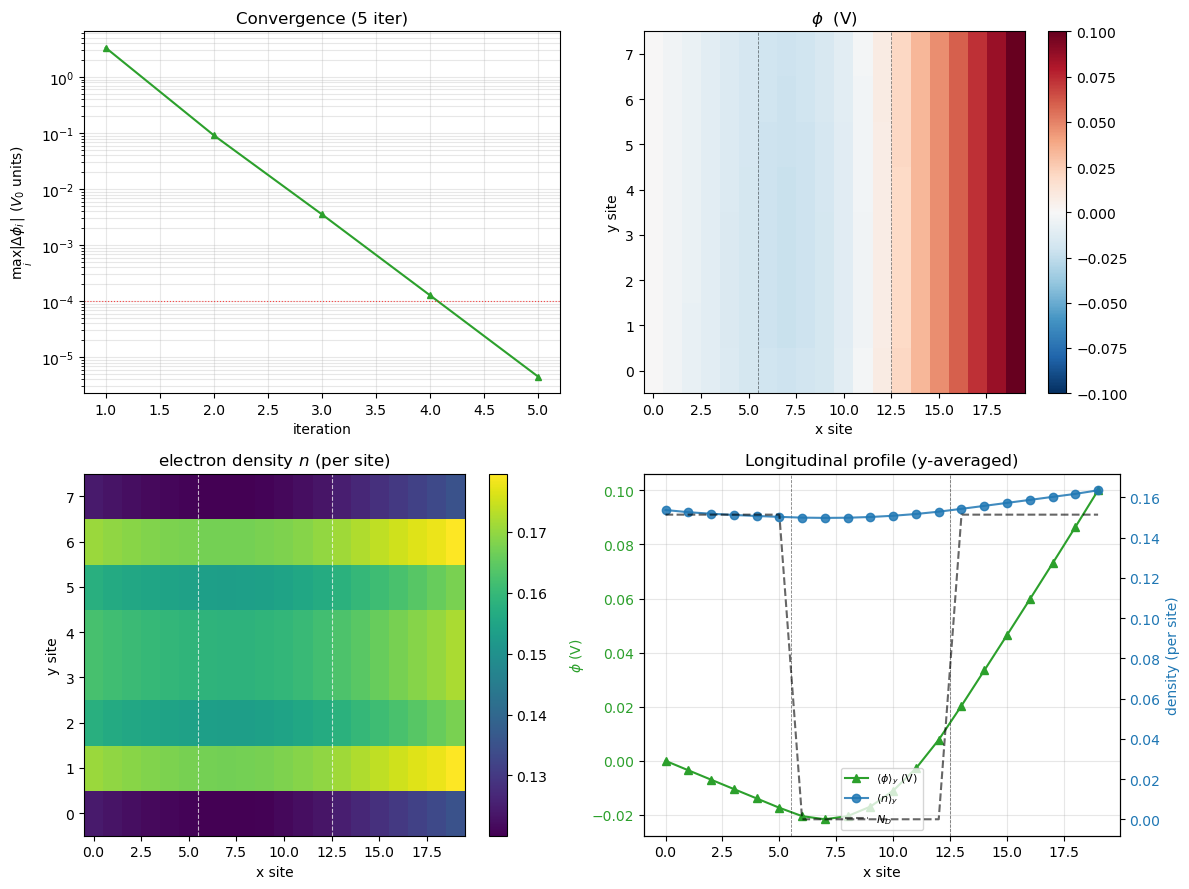

In [ ]:
"""
Self-consistent Poisson-NEGF on a 2D tight-binding strip — dolfinx.

Same algorithm as the 1D demo (Newton with the analytical Ahn-Hong Jacobian)
but now:
  * the Hamiltonian is a 2D square lattice (Nx × Ny sites)
  * each lead self-energy is an Ny × Ny matrix on the contact column
    (built by transverse-mode decomposition; no Sancho-Rubio iteration
    needed for the simple square-lattice lead used in the demo)
  * the Poisson side is a 2D rectangular FEM mesh in dolfinx, with one
    P1 dof per TB site
  * Dirichlet on the source (x=0) / drain (x=Nx-1) edges; Neumann on
    top/bottom (y) — i.e. an isolated wire with metallic contacts.

The whole self-consistency loop is a single LinearProblem.solve() per
Newton iteration, exactly the same pattern as your 3D code.

Run
---
    python poisson_negf_2d_dolfinx.py

Requires: dolfinx 0.7+, petsc4py, numpy, matplotlib.
"""

from __future__ import annotations

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from mpi4py import MPI
import ufl
from dolfinx import fem, mesh
from dolfinx.fem.petsc import LinearProblem
from petsc4py import PETSc


# --------------------------------------------------------------------- #
#  Physical constants and scaling                                       #
# --------------------------------------------------------------------- #
q     = 1.602e-19                # C
eps0  = 8.854e-12                # F/m
kT    = 0.026                    # eV at T = 300 K
V0    = kT                       # voltage scale
L0    = 5e-10                    # 5 A site spacing
eps_r = 11.7

# Effective device thickness in the suppressed z direction (sets alpha).
# Tune so phi sits at a physical scale (~ tens of mV) for V_DS = 0.10 V.
N_thick       = 200.0
alpha_poisson = q / (eps0 * N_thick * L0 * V0)


# --------------------------------------------------------------------- #
#  2D tight-binding device                                              #
# --------------------------------------------------------------------- #
Nx, Ny  = 20, 8
N_sites = Nx * Ny
t_hop   = 1.0                    # eV; band [-4t, 4t] for 2D square lattice
eta_negf = 5e-3                  # broadening; needs to be > 0 for convergence

mu_ref          = -2.0           # eV; in lower half of the 2D band
V_applied_left  = 0.0
V_applied_right = 0.10


def site_index(i: int, j: int) -> int:
    """(i, j) -> flat TB index, with i = transport column, j = transverse row."""
    return i * Ny + j


# Build H0 with NN hopping in x (transport) and y (transverse).
H0 = np.zeros((N_sites, N_sites))
for _i in range(Nx):
    for _j in range(Ny):
        _k = site_index(_i, _j)
        if _i + 1 < Nx:
            _kp = site_index(_i + 1, _j)
            H0[_k, _kp] = -t_hop;  H0[_kp, _k] = -t_hop
        if _j + 1 < Ny:
            _kp = site_index(_i, _j + 1)
            H0[_k, _kp] = -t_hop;  H0[_kp, _k] = -t_hop


# --------------------------------------------------------------------- #
#  2D lead self-energy via transverse-mode decomposition                #
# --------------------------------------------------------------------- #
# Each lead is a semi-infinite 2D strip with hard-wall BC in y.  Decompose
# in transverse modes:
#   eps_n  = -2 t cos(n π / (Ny+1))             (n = 1..Ny)
#   φ_n(j) = sqrt(2/(Ny+1)) sin((j+1) n π / (Ny+1))
# In each mode the longitudinal lead is a 1D chain → analytic surface GF.
# Σ in site basis on the contact column = U diag(σ_n) U^T  with σ_n = t² g_s,n.
mode_n     = np.arange(1, Ny + 1)
eps_modes  = -2.0 * t_hop * np.cos(mode_n * np.pi / (Ny + 1))
_j_idx     = np.arange(Ny) + 1
U_trans    = (np.sqrt(2.0 / (Ny + 1))
              * np.sin(np.outer(_j_idx, mode_n) * np.pi / (Ny + 1)))   # (Ny,Ny)


def lead_self_energies(E: float, eta: float = eta_negf):
    """Σ_L, Σ_R as full N_sites × N_sites matrices.

    Lead bands shift with V_applied: at lab energy E the biased lead's GF
    is Σ((E + V_applied) - eps_n) for each transverse mode n.
    """
    sigL = np.zeros((N_sites, N_sites), dtype=complex)
    sigR = np.zeros((N_sites, N_sites), dtype=complex)

    zL = (E + V_applied_left)  + 1j * eta
    zR = (E + V_applied_right) + 1j * eta

    sqL = np.sqrt((zL - eps_modes) ** 2 - 4.0 * t_hop ** 2)
    sqR = np.sqrt((zR - eps_modes) ** 2 - 4.0 * t_hop ** 2)
    sqL = np.where(sqL.imag < 0, -sqL, sqL)        # retarded branch
    sqR = np.where(sqR.imag < 0, -sqR, sqR)
    sig_modes_L = t_hop ** 2 * (zL - eps_modes - sqL) / (2.0 * t_hop ** 2)
    sig_modes_R = t_hop ** 2 * (zR - eps_modes - sqR) / (2.0 * t_hop ** 2)

    sigma_L_block = (U_trans * sig_modes_L) @ U_trans.T
    sigma_R_block = (U_trans * sig_modes_R) @ U_trans.T

    sigL[:Ny, :Ny] = sigma_L_block
    offR = (Nx - 1) * Ny
    sigR[offR: offR + Ny, offR: offR + Ny] = sigma_R_block
    return sigL, sigR


def negf_density_and_jacobian(
    phi_site: np.ndarray,
    mu_L: float,
    mu_R: float,
    E_grid: np.ndarray,
    eta: float = eta_negf,
    return_jacobian: bool = True,
):
    """phi_site (length N_sites) is in V0 units; H_eff = H0 - V0 diag(phi)."""
    H_eff = H0 - V0 * np.diag(phi_site)
    n     = np.zeros(N_sites)
    J     = np.zeros(N_sites) if return_jacobian else None

    dE  = np.gradient(E_grid)
    I_N = np.eye(N_sites, dtype=complex)

    for k, E in enumerate(E_grid):
        sigL, sigR = lead_self_energies(E, eta)

        M   = (E + 1j * eta) * np.eye(N_sites) - H_eff - sigL - sigR
        G_R = np.linalg.solve(M, I_N)
        G_A = G_R.conj().T

        Gamma_L = 1j * (sigL - sigL.conj().T)
        Gamma_R = 1j * (sigR - sigR.conj().T)

        fL = 1.0 / (1.0 + np.exp(np.clip((E - mu_L) / kT, -200, 200)))
        fR = 1.0 / (1.0 + np.exp(np.clip((E - mu_R) / kT, -200, 200)))
        Sigma_lesser = 1j * (fL * Gamma_L + fR * Gamma_R)
        G_lesser = G_R @ Sigma_lesser @ G_A

        diag_GR    = np.diag(G_R)
        diag_Gless = np.diag(G_lesser)

        n_E = (-1j * diag_Gless).real / (2.0 * np.pi)
        n  += n_E * dE[k]

        if return_jacobian:
            # diagonal Ahn-Hong Jacobian: dn_i/dphi_i = -(V0/π) Re(G^R_ii) Im(G^<_ii)
            J_E = -(V0 / np.pi) * (diag_GR.real * diag_Gless.imag)
            J  += J_E * dE[k]

    return (n, J) if return_jacobian else n


# --------------------------------------------------------------------- #
#  Define the doping by NEGF equilibrium (charge-neutral S/D at V=0)    #
# --------------------------------------------------------------------- #
print("computing equilibrium NEGF density to fix doping ...")
E_grid = np.linspace(-4.5, 4.5, 601)
_t0 = time.time()
n_eq = negf_density_and_jacobian(np.zeros(N_sites), mu_ref, mu_ref,
                                 E_grid, return_jacobian=False)
print(f"   done in {time.time() - _t0:.1f}s, mean n_eq = {n_eq.mean():.4f}")

# Use the equilibrium density per row as the doping density in S/D regions
# (so the doped regions are exactly charge-neutral when phi = 0).
n_eq_grid    = n_eq.reshape(Nx, Ny)
Nd_per_row   = n_eq_grid[Nx // 2]                    # midstrip row pattern
Nd_2d        = np.zeros((Nx, Ny))
src_end      = Nx // 3
drn_start    = 2 * Nx // 3
Nd_2d[: src_end, :]    = Nd_per_row[None, :]
Nd_2d[drn_start:, :]   = Nd_per_row[None, :]
Nd_flat = Nd_2d.flatten()


# --------------------------------------------------------------------- #
#  FEM setup: 2D rectangular mesh, one P1 dof per TB site               #
# --------------------------------------------------------------------- #
# Use a structured triangular mesh of size (Nx-1) × (Ny-1) with
# Nx*Ny vertices; P1 places one dof at each vertex.
domain = mesh.create_rectangle(
    MPI.COMM_WORLD,
    points=[(0.0, 0.0), (float(Nx - 1), float(Ny - 1))],
    n=[Nx - 1, Ny - 1],
    cell_type=mesh.CellType.triangle,
)
V = fem.functionspace(domain, ("Lagrange", 1))

# Build site <-> dof maps using the dof coordinates (lex-sort by x then y).
dof_xy = V.tabulate_dof_coordinates()[:, :2]
site_to_dof = np.lexsort((dof_xy[:, 1], dof_xy[:, 0])).astype(np.int32)
dof_to_site = np.argsort(site_to_dof).astype(np.int32)


def site_array_to_dof(arr_site: np.ndarray) -> np.ndarray:
    out = np.empty_like(arr_site)
    out[site_to_dof] = arr_site
    return out


def dof_array_to_site(arr_dof: np.ndarray) -> np.ndarray:
    out = np.empty_like(arr_dof)
    out[dof_to_site] = arr_dof
    return out


# Field functions
phi   = fem.Function(V, name="phi")
n_fn  = fem.Function(V, name="n")
J_fn  = fem.Function(V, name="J")
Nd_fn = fem.Function(V, name="Nd")

Nd_fn.x.array[:] = site_array_to_dof(Nd_flat)
phi.x.array[:]   = 0.0


# Dirichlet BCs on left (x=0) and right (x=Nx-1) edges; Neumann elsewhere.
def left_edge(x):  return np.isclose(x[0], 0.0)
def right_edge(x): return np.isclose(x[0], float(Nx - 1))

left_dofs  = fem.locate_dofs_geometrical(V, left_edge)
right_dofs = fem.locate_dofs_geometrical(V, right_edge)

bc_left  = fem.dirichletbc(PETSc.ScalarType(V_applied_left  / V0),
                           left_dofs,  V)
bc_right = fem.dirichletbc(PETSc.ScalarType(V_applied_right / V0),
                           right_dofs, V)
bcs = [bc_left, bc_right]
fem.set_bc(phi.x.array, bcs)


# --------------------------------------------------------------------- #
#  Forms (same structure as your 3D code)                               #
# --------------------------------------------------------------------- #
u, v = ufl.TrialFunction(V), ufl.TestFunction(V)

a_newton_ufl = (eps_r * ufl.inner(ufl.grad(u), ufl.grad(v))
                + alpha_poisson * J_fn * u * v) * ufl.dx
L_newton_ufl = (alpha_poisson * (Nd_fn - n_fn + J_fn * phi) * v) * ufl.dx

phi_candidate = fem.Function(V, name="phi_candidate")

newton_problem = LinearProblem(
    a_newton_ufl, L_newton_ufl,
    u=phi_candidate, bcs=bcs,
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
    petsc_options_prefix="negf_newton_2d_",
)


# --------------------------------------------------------------------- #
#  Newton with analytical Jacobian                                      #
# --------------------------------------------------------------------- #
def solve_newton_analytical(E_grid, max_iter=20, tol=1e-4,
                             mix=1.0, verbose=True):
    phi.x.array[:] = 0.0
    fem.set_bc(phi.x.array, bcs)
    mu_L = mu_ref - V_applied_left
    mu_R = mu_ref - V_applied_right

    history = []
    for it in range(max_iter):
        t_iter = time.time()
        phi_site = dof_array_to_site(phi.x.array)
        n_site, J_site = negf_density_and_jacobian(
            phi_site, mu_L, mu_R, E_grid, return_jacobian=True)

        n_fn.x.array[:] = site_array_to_dof(n_site)
        J_fn.x.array[:] = site_array_to_dof(J_site)

        newton_problem.solve()       # writes phi_candidate

        delta = phi_candidate.x.array - phi.x.array
        phi.x.array[:] = phi.x.array + mix * delta

        err = float(np.max(np.abs(delta)))
        history.append(err)
        if verbose:
            print(f"   Newton-AN {it+1:3d}: |dphi|_max = {err:.3e}"
                  f"   ({time.time() - t_iter:.1f}s)")
        if err < tol:
            break
    return phi.x.array.copy(), history


# --------------------------------------------------------------------- #
#  Drive                                                                #
# --------------------------------------------------------------------- #
if __name__ == "__main__":
    print("=" * 64)
    print("  2D self-consistent Poisson-NEGF (dolfinx)")
    print(f"  device:   {Nx} × {Ny} = {N_sites} sites, t = {t_hop} eV")
    print(f"  doping:   Nd = {Nd_per_row.mean():.3f} per site (S and D thirds)")
    print(f"  bias:     V_DS = {V_applied_right - V_applied_left} V")
    print(f"  alpha:    {alpha_poisson:.3e}")
    print("=" * 64)

    print("\nNewton with analytical Ahn-Hong Jacobian ...")
    phi_dof, history = solve_newton_analytical(E_grid, verbose=True)

    # --------- post-process --------------------------------------------
    phi_site = dof_array_to_site(phi_dof)
    n_site   = negf_density_and_jacobian(
        phi_site, mu_ref - V_applied_left, mu_ref - V_applied_right,
        E_grid, return_jacobian=False)

    phi_2d = phi_site.reshape(Nx, Ny) * V0     # in volts
    n_2d   = n_site.reshape(Nx, Ny)

    # --------- plot ----------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # convergence
    ax = axes[0, 0]
    ax.semilogy(np.arange(1, len(history) + 1), history, "^-",
                color="C2", ms=5)
    ax.axhline(1e-4, color="red", ls=":", lw=0.8, alpha=0.7)
    ax.set_xlabel("iteration")
    ax.set_ylabel(r"$\max_i |\Delta\phi_i|$ ($V_0$ units)")
    ax.set_title(f"Convergence ({len(history)} iter)")
    ax.grid(alpha=0.3, which="both")

    # phi heatmap
    ax = axes[0, 1]
    im = ax.imshow(phi_2d.T, origin="lower", aspect="auto",
                   cmap="RdBu_r",
                   vmin=-max(abs(phi_2d.min()), abs(phi_2d.max())),
                   vmax= max(abs(phi_2d.min()), abs(phi_2d.max())),
                   extent=[-0.5, Nx - 0.5, -0.5, Ny - 0.5])
    ax.set_title(r"$\phi$  (V)")
    ax.set_xlabel("x site");  ax.set_ylabel("y site")
    ax.axvline(src_end - 0.5,   color="k", lw=0.6, ls="--", alpha=0.5)
    ax.axvline(drn_start - 0.5, color="k", lw=0.6, ls="--", alpha=0.5)
    plt.colorbar(im, ax=ax)

    # n heatmap
    ax = axes[1, 0]
    im = ax.imshow(n_2d.T, origin="lower", aspect="auto", cmap="viridis",
                   extent=[-0.5, Nx - 0.5, -0.5, Ny - 0.5])
    ax.set_title("electron density $n$ (per site)")
    ax.set_xlabel("x site");  ax.set_ylabel("y site")
    ax.axvline(src_end - 0.5,   color="w", lw=0.8, ls="--", alpha=0.7)
    ax.axvline(drn_start - 0.5, color="w", lw=0.8, ls="--", alpha=0.7)
    plt.colorbar(im, ax=ax)

    # longitudinal cuts (averaged over y to suppress transverse modes)
    ax = axes[1, 1]
    x = np.arange(Nx)
    ax.plot(x, phi_2d.mean(axis=1), "C2^-", label=r"$\langle\phi\rangle_y$ (V)")
    ax.set_xlabel("x site")
    ax.set_ylabel(r"$\phi$ (V)", color="C2")
    ax.tick_params(axis="y", labelcolor="C2")
    ax.axvline(src_end - 0.5,   color="k", lw=0.6, ls="--", alpha=0.5)
    ax.axvline(drn_start - 0.5, color="k", lw=0.6, ls="--", alpha=0.5)
    ax.grid(alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(x, n_2d.mean(axis=1),       "C0o-", alpha=0.85,
             label=r"$\langle n\rangle_y$")
    ax2.plot(x, Nd_2d.mean(axis=1),      "k--", alpha=0.6, label=r"$N_D$")
    ax2.set_ylabel("density (per site)", color="C0")
    ax2.tick_params(axis="y", labelcolor="C0")
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="lower center")
    ax.set_title("Longitudinal profile (y-averaged)")

    plt.tight_layout()
    plt.savefig("coupled_negf_poisson_2d.png", dpi=130)
    print("\nSaved plot to coupled_negf_poisson_2d.png")

    print("\n" + "=" * 64)
    print(f"  Iterations:       {len(history)}")
    print(f"  NEGF sweeps:      {len(history) + 1}    (one extra for n_eq doping)")
    print(f"  Final residual:   {history[-1]:.2e}")
    print(f"  phi range:        [{phi_2d.min():.3f}, {phi_2d.max():.3f}] V")
    print(f"  n range:          [{n_2d.min():.3f}, {n_2d.max():.3f}] per site")
    print("=" * 64)

computing equilibrium NEGF density to fix doping ...
   done in 43.0s, mean n_eq = 0.5904
  2D Liang Fu Poisson-NEGF (dolfinx)
  device:   20 × 8 = 160 sites; orb dim = 320
  v_k = 1.0, λ = 0.0, t_W = 0.0, E_0 = 0.0
  Nd:       0.560 per site (uniform)
  V_DS:     0.100 V
  V_top:    +0.000 V    V_bot: +0.000 V
  alpha:    6.959e+00

Newton with analytical Ahn-Hong Jacobian ...
   Newton-AN   1: |dphi|_max = 2.615e+00   (43.0s)
   Newton-AN   2: |dphi|_max = 7.717e-01   (41.4s)
   Newton-AN   3: |dphi|_max = 2.270e-01   (41.0s)
   Newton-AN   4: |dphi|_max = 6.658e-02   (41.4s)
   Newton-AN   5: |dphi|_max = 1.951e-02   (41.3s)
   Newton-AN   6: |dphi|_max = 5.715e-03   (40.9s)
   Newton-AN   7: |dphi|_max = 1.688e-03   (41.4s)
   Newton-AN   8: |dphi|_max = 5.415e-04   (40.8s)
   Newton-AN   9: |dphi|_max = 1.723e-04   (40.9s)
   Newton-AN  10: |dphi|_max = 5.444e-05   (41.4s)

Final NEGF sweep with spin densities ...

Channel-integrated spin (sum over channel sites):
  ⟨S_x⟩  = +0.00

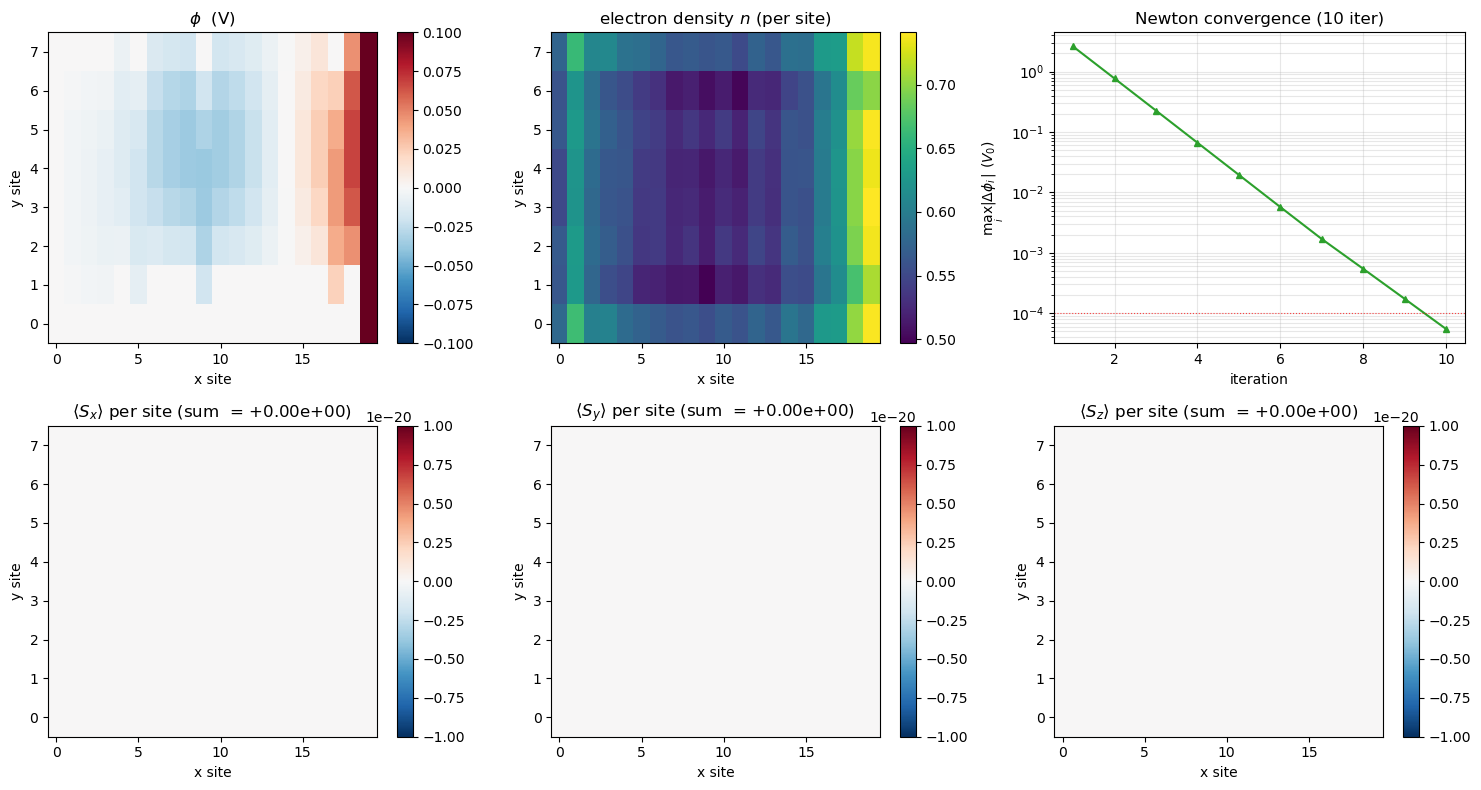

In [1]:
"""
Self-consistent Poisson-NEGF on a 2D Liang Fu (TI surface state) device — dolfinx.

Same scaffolding as poisson_negf_2d_dolfinx.py (Newton with the analytical
Ahn-Hong Jacobian, dolfinx P1 Poisson, Dirichlet x-edges).  The device
Hamiltonian is

    H(k) = E_0 σ_0 + v_k (k_x σ_y - k_y σ_x) + λ (k_x³ - 3 k_x k_y²) σ_z
           + t_W [4 - 2 cos(k_x a) - 2 cos(k_y a)] σ_0          (*)

discretized in BOTH x and y on an Nx × Ny lattice (each (i,j) site carries
a 2-component spinor; N_orb = 2·Nx·Ny).

(*) The last line is a **Wilson kinetic term**.  The naive centered-difference
discretization of pure Dirac (k_α → sin(k_α a)/a) creates four Dirac cones
in the 2D BZ — at (0,0), (π/a, 0), (0, π/a), (π/a, π/a).  The doublers at
(π,0) and (0,π) carry opposite helicity to the one at (0,0), and at λ = 0
their Edelstein contributions cancel pairwise.  Numerically this manifests
as <S_x> = <S_y> = 0 EXACTLY (a "path-product" symmetry: every closed walk
on the lattice picks up only σ_0 and σ_z factors when each x-hop carries
σ_y and each y-hop carries σ_x).
The Wilson term lifts the doublers at the BZ corners by ~8 t_W, while leaving
the (0,0) cone intact at small k, and it mixes σ_0 into the x- and y-hops
so closed-loop products can produce σ_x and σ_y.  Set t_W = 0 to recover
the doubler-protected case (NEGF disagrees with Boltzmann); set
t_W ~ 0.1–0.3 for clean Edelstein agreement.

Hopping table (combining all of the above):

    (Δi, Δj)    block on (i,j) → (i+Δi, j+Δj)
    --------    -------------------------------------------------------
    ( 0, 0)     E_0 σ_0  +  4 t_W σ_0
    (+1, 0)     -i v/(2a) σ_y  +  2iλ/a³ σ_z  -  t_W σ_0
    ( 0,+1)     +i v/(2a) σ_x  -  t_W σ_0
    (+1,+1)     -3iλ/(2a³) σ_z
    (+1,-1)     -3iλ/(2a³) σ_z
    (+2, 0)     +iλ/(2a³) σ_z

Lead self-energies via Sancho-Rubio with super-cell pairing in x (super-cell
= 2 adjacent x-slices, dim 4Ny), since the +2 hop in x makes ordinary
single-slice Sancho-Rubio insufficient.

Run
---
    python poisson_negf_2d_LiangFu_dolfinx.py

Toggles:
  * lam        — warping strength
  * t_W        — Wilson regulator (lifts BZ-corner doublers)
  * V_top, V_bot  — asymmetric gating (set both to 0 for y-mirror-symmetric)
  * V_applied_right - V_applied_left  — bias V_DS
"""

from __future__ import annotations

import time
import numpy as np
import matplotlib.pyplot as plt

from mpi4py import MPI
import ufl
from dolfinx import fem, mesh
from dolfinx.fem.petsc import LinearProblem
from petsc4py import PETSc


# --------------------------------------------------------------------- #
#  Physical constants and scaling                                       #
# --------------------------------------------------------------------- #
q     = 1.602e-19                # C
eps0  = 8.854e-12                # F/m
kT    = 0.026                    # eV at T = 300 K
V0    = kT                       # voltage scale
L0    = 5e-10                    # 5 A site spacing
eps_r = 11.7

N_thick       = 200.0
alpha_poisson = q / (eps0 * N_thick * L0 * V0)


# --------------------------------------------------------------------- #
#  2D Liang Fu device                                                   #
# --------------------------------------------------------------------- #
Nx, Ny  = 20, 8                  # Nx must be EVEN (super-cell pairing in x)
assert Nx % 2 == 0
N_sites = Nx * Ny
N_orb   = 2 * N_sites            # spin doubling

a       = 1.0                    # lattice spacing
v_k     = 1.0                    # Dirac velocity
lam     = 0.0                    # warping
t_W     = 0.0                   # Wilson regulator (set 0 to test doubler protection)
E0_band = 0.0                    # Dirac point at zero
eta_negf = 5e-3

mu_ref          = 0.0            # near the Dirac point
V_applied_left  = 0.0
V_applied_right = 0.10           # V_DS

# Asymmetric top/bottom Dirichlet (V).  Set both to 0.0 for y-mirror symmetric.
V_top           = 0.0
V_bot           = 0.0


def site_index(i: int, j: int) -> int:
    return i * Ny + j


# --------------------------------------------------------------------- #
#  Pauli matrices                                                       #
# --------------------------------------------------------------------- #
I2 = np.eye(2, dtype=complex)
sx = np.array([[0,  1 ], [1,   0]], dtype=complex)
sy = np.array([[0, -1j], [1j,  0]], dtype=complex)
sz = np.array([[1,  0 ], [0,  -1]], dtype=complex)


# --------------------------------------------------------------------- #
#  Slice operators (acting on a single x-slice; dim 2*Ny)               #
# --------------------------------------------------------------------- #
def build_H_slice_00():
    """Intra-x-slice block.
    On-site:        (E_0 + 4 t_W) σ_0
    (j) -> (j+1):   +i v/(2a) σ_x  -  t_W σ_0
    """
    H = np.zeros((2 * Ny, 2 * Ny), dtype=complex)
    onsite = (E0_band + 4.0 * t_W) * I2
    yhop   = +1j * v_k / (2 * a) * sx + (-t_W) * I2
    for j in range(Ny):
        H[2*j: 2*j+2, 2*j: 2*j+2] = onsite
        if j + 1 < Ny:
            H[2*j: 2*j+2, 2*(j+1): 2*(j+1)+2] = yhop
            H[2*(j+1): 2*(j+1)+2, 2*j: 2*j+2] = yhop.conj().T
    return H


def build_H_slice_01():
    """x-slice n -> n+1 hopping.
    diag in y :  -i v/(2a) σ_y  +  2iλ/a³ σ_z  -  t_W σ_0
    j -> j±1  :  -3iλ/(2a³) σ_z
    """
    H = np.zeros((2 * Ny, 2 * Ny), dtype=complex)
    diag_blk = (-1j * v_k / (2 * a) * sy
                + 2j * lam / a**3 * sz
                + (-t_W) * I2)
    off_blk  = -3j * lam / (2 * a**3) * sz
    for j in range(Ny):
        H[2*j: 2*j+2, 2*j: 2*j+2] = diag_blk
        if j + 1 < Ny:
            H[2*j: 2*j+2, 2*(j+1): 2*(j+1)+2] = off_blk
        if j - 1 >= 0:
            H[2*j: 2*j+2, 2*(j-1): 2*(j-1)+2] = off_blk
    return H


def build_H_slice_02():
    """x-slice n -> n+2 hopping:  +iλ/(2a³) σ_z, diagonal in y."""
    H = np.zeros((2 * Ny, 2 * Ny), dtype=complex)
    blk = +1j * lam / (2 * a**3) * sz
    for j in range(Ny):
        H[2*j: 2*j+2, 2*j: 2*j+2] = blk
    return H


def build_H_device(H00, H01, H02):
    H = np.zeros((N_orb, N_orb), dtype=complex)
    n_slice = 2 * Ny
    for i in range(Nx):
        H[i*n_slice: (i+1)*n_slice, i*n_slice: (i+1)*n_slice] = H00
        if i + 1 < Nx:
            H[i*n_slice: (i+1)*n_slice, (i+1)*n_slice: (i+2)*n_slice] = H01
            H[(i+1)*n_slice: (i+2)*n_slice, i*n_slice: (i+1)*n_slice] = H01.conj().T
        if i + 2 < Nx:
            H[i*n_slice: (i+1)*n_slice, (i+2)*n_slice: (i+3)*n_slice] = H02
            H[(i+2)*n_slice: (i+3)*n_slice, i*n_slice: (i+1)*n_slice] = H02.conj().T
    return H


def build_super_cell(H00, H01, H02):
    n_slice = 2 * Ny
    n_cell  = 2 * n_slice
    H_cell = np.zeros((n_cell, n_cell), dtype=complex)
    H_cell[:n_slice, :n_slice] = H00
    H_cell[n_slice:, n_slice:] = H00
    H_cell[:n_slice, n_slice:] = H01
    H_cell[n_slice:, :n_slice] = H01.conj().T
    T_cell = np.zeros((n_cell, n_cell), dtype=complex)
    T_cell[:n_slice, :n_slice] = H02
    T_cell[n_slice:, n_slice:] = H02
    T_cell[n_slice:, :n_slice] = H01
    return H_cell, T_cell


def sancho_rubio(z, H_c, T_c, max_iter=120, tol=1e-13):
    """g_s satisfies  g_s = (z I - H_c - T_c† g_s T_c)^{-1}."""
    n   = H_c.shape[0]
    I_n = np.eye(n, dtype=complex)
    H_eff = H_c.copy(); H_s = H_c.copy()
    alpha = T_c.copy(); beta = T_c.conj().T.copy()
    for _ in range(max_iter):
        g  = np.linalg.solve(z * I_n - H_eff, I_n)
        ag = alpha @ g; bg = beta @ g
        H_s   = H_s   + ag @ beta
        H_eff = H_eff + ag @ beta + bg @ alpha
        alpha = ag @ alpha; beta = bg @ beta
        if max(np.max(np.abs(alpha)), np.max(np.abs(beta))) < tol:
            break
    return np.linalg.solve(z * I_n - H_s, I_n)


# --------------------------------------------------------------------- #
#  Pre-build slice + super-cell operators and the device H              #
# --------------------------------------------------------------------- #
H_00 = build_H_slice_00()
H_01 = build_H_slice_01()
H_02 = build_H_slice_02()
H0   = build_H_device(H_00, H_01, H_02)
H_cell, T_cell = build_super_cell(H_00, H_01, H_02)
N_cell = H_cell.shape[0]


def cache_lead_self_energies(E_grid, V_L, V_R, eta=eta_negf):
    """Σ_L on the FIRST super-cell, Σ_R on the LAST."""
    cL = np.empty((len(E_grid), N_cell, N_cell), dtype=complex)
    cR = np.empty((len(E_grid), N_cell, N_cell), dtype=complex)
    for k, E in enumerate(E_grid):
        zL = (E + V_L) + 1j * eta
        zR = (E + V_R) + 1j * eta
        gL = sancho_rubio(zL, H_cell, T_cell)
        gR = sancho_rubio(zR, H_cell, T_cell.conj().T)
        cL[k] = T_cell.conj().T @ gL @ T_cell
        cR[k] = T_cell @ gR @ T_cell.conj().T
    return cL, cR


# --------------------------------------------------------------------- #
#  NEGF density + Jacobian (+ optional spin densities)                  #
# --------------------------------------------------------------------- #
def negf_density_and_jacobian(
    phi_site, mu_L, mu_R, E_grid, SL_cache, SR_cache,
    eta=eta_negf, return_jacobian=True, return_spin=False,
):
    """phi_site (length N_sites) is in V0 units.
    H_eff = H0 - V0 · diag(phi)  with phi applied to BOTH spin components."""
    diag_pot = np.repeat(V0 * phi_site, 2)
    H_eff = H0 - np.diag(diag_pot)

    n = np.zeros(N_sites)
    J = np.zeros(N_sites) if return_jacobian else None
    S = np.zeros((3, N_sites)) if return_spin else None

    dE  = np.gradient(E_grid)
    I_N = np.eye(N_orb, dtype=complex)
    idx_lo = np.arange(N_sites) * 2
    idx_up = idx_lo + 1

    for k, E in enumerate(E_grid):
        SL = SL_cache[k]; SR = SR_cache[k]

        M = (E + 1j * eta) * I_N - H_eff
        M[:N_cell, :N_cell] -= SL
        M[-N_cell:, -N_cell:] -= SR

        G_R = np.linalg.solve(M, I_N); G_A = G_R.conj().T

        Gamma_L = 1j * (SL - SL.conj().T)
        Gamma_R = 1j * (SR - SR.conj().T)

        fL = 1.0 / (1.0 + np.exp(np.clip((E - mu_L) / kT, -200, 200)))
        fR = 1.0 / (1.0 + np.exp(np.clip((E - mu_R) / kT, -200, 200)))

        Sigma_lesser = np.zeros((N_orb, N_orb), dtype=complex)
        Sigma_lesser[:N_cell, :N_cell]   = 1j * fL * Gamma_L
        Sigma_lesser[-N_cell:, -N_cell:] = 1j * fR * Gamma_R

        G_lesser = G_R @ Sigma_lesser @ G_A

        diag_GR    = np.diag(G_R)
        diag_Gless = np.diag(G_lesser)

        n_E_orb  = (-1j * diag_Gless).real / (2.0 * np.pi)
        n_E_site = n_E_orb.reshape(N_sites, 2).sum(axis=1)
        n += n_E_site * dE[k]

        if return_jacobian:
            J_E_orb  = -(V0 / np.pi) * (diag_GR.real * diag_Gless.imag)
            J_E_site = J_E_orb.reshape(N_sites, 2).sum(axis=1)
            J += J_E_site * dE[k]

        if return_spin:
            G_off = G_lesser[idx_lo, idx_up]
            S[0] += (G_off.imag / (2.0 * np.pi)) * dE[k]
            S[1] += (-G_off.real / (2.0 * np.pi)) * dE[k]
            S[2] += ((diag_Gless[idx_lo].imag - diag_Gless[idx_up].imag)
                     / (4.0 * np.pi)) * dE[k]

    out = (n,)
    if return_jacobian: out = out + (J,)
    if return_spin:     out = out + (S,)
    return out if len(out) > 1 else out[0]


# --------------------------------------------------------------------- #
#  Energy grid and lead caches                                          #
# --------------------------------------------------------------------- #
print("computing equilibrium NEGF density to fix doping ...")
E_grid = np.linspace(-3.5, 3.5, 401)

SL_eq, SR_eq = cache_lead_self_energies(E_grid, 0.0, 0.0)

_t0 = time.time()
n_eq = negf_density_and_jacobian(
    np.zeros(N_sites), mu_ref, mu_ref, E_grid, SL_eq, SR_eq,
    return_jacobian=False, return_spin=False)
print(f"   done in {time.time() - _t0:.1f}s, mean n_eq = {n_eq.mean():.4f}")

n_eq_grid  = n_eq.reshape(Nx, Ny)
Nd_per_row = n_eq_grid[Nx // 2]
Nd_2d      = np.zeros((Nx, Ny))
src_end    = Nx // 3
drn_start  = 2 * Nx // 3
Nd_2d[: src_end, :]   = Nd_per_row[None, :]
Nd_2d[drn_start:, :]  = Nd_per_row[None, :]
Nd_flat = Nd_2d.flatten()


SL_cache, SR_cache = cache_lead_self_energies(E_grid,
                                              V_applied_left, V_applied_right)


# --------------------------------------------------------------------- #
#  FEM setup                                                            #
# --------------------------------------------------------------------- #
domain = mesh.create_rectangle(
    MPI.COMM_WORLD,
    points=[(0.0, 0.0), (float(Nx - 1), float(Ny - 1))],
    n=[Nx - 1, Ny - 1],
    cell_type=mesh.CellType.triangle,
)
V = fem.functionspace(domain, ("Lagrange", 1))

dof_xy = V.tabulate_dof_coordinates()[:, :2]
site_to_dof = np.lexsort((dof_xy[:, 1], dof_xy[:, 0])).astype(np.int32)
dof_to_site = np.argsort(site_to_dof).astype(np.int32)


def site_array_to_dof(arr_site):
    out = np.empty_like(arr_site); out[site_to_dof] = arr_site; return out


def dof_array_to_site(arr_dof):
    out = np.empty_like(arr_dof); out[dof_to_site] = arr_dof; return out


phi   = fem.Function(V, name="phi")
n_fn  = fem.Function(V, name="n")
J_fn  = fem.Function(V, name="J")
Nd_fn = fem.Function(V, name="Nd")

Nd_fn.x.array[:] = site_array_to_dof(Nd_flat)
phi.x.array[:]   = 0.0


def left_edge(x):  return np.isclose(x[0], 0.0)
def right_edge(x): return np.isclose(x[0], float(Nx - 1))
def top_edge(x):   return np.isclose(x[1], float(Ny - 1))
def bot_edge(x):   return np.isclose(x[1], 0.0)

left_dofs  = fem.locate_dofs_geometrical(V, left_edge)
right_dofs = fem.locate_dofs_geometrical(V, right_edge)
top_dofs   = fem.locate_dofs_geometrical(V, top_edge)
bot_dofs   = fem.locate_dofs_geometrical(V, bot_edge)

bc_top   = fem.dirichletbc(PETSc.ScalarType(V_top  / V0), top_dofs,   V)
bc_bot   = fem.dirichletbc(PETSc.ScalarType(V_bot  / V0), bot_dofs,   V)
bc_left  = fem.dirichletbc(PETSc.ScalarType(V_applied_left  / V0), left_dofs,  V)
bc_right = fem.dirichletbc(PETSc.ScalarType(V_applied_right / V0), right_dofs, V)

# Order: top/bottom first, then left/right wins at corner dofs
bcs = [bc_top, bc_bot, bc_left, bc_right]
fem.set_bc(phi.x.array, bcs)


# --------------------------------------------------------------------- #
#  Forms                                                                #
# --------------------------------------------------------------------- #
u, v = ufl.TrialFunction(V), ufl.TestFunction(V)

a_newton_ufl = (eps_r * ufl.inner(ufl.grad(u), ufl.grad(v))
                + alpha_poisson * J_fn * u * v) * ufl.dx
L_newton_ufl = (alpha_poisson * (Nd_fn - n_fn + J_fn * phi) * v) * ufl.dx

phi_candidate = fem.Function(V, name="phi_candidate")
newton_problem = LinearProblem(
    a_newton_ufl, L_newton_ufl,
    u=phi_candidate, bcs=bcs,
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
    petsc_options_prefix="negf_newton_2d_lf_",
)


# --------------------------------------------------------------------- #
#  Newton                                                               #
# --------------------------------------------------------------------- #
def solve_newton_analytical(E_grid, max_iter=20, tol=1e-4, mix=1.0, verbose=True):
    phi.x.array[:] = 0.0
    fem.set_bc(phi.x.array, bcs)
    mu_L = mu_ref - V_applied_left
    mu_R = mu_ref - V_applied_right

    history = []
    for it in range(max_iter):
        t_iter = time.time()
        phi_site = dof_array_to_site(phi.x.array)
        n_site, J_site = negf_density_and_jacobian(
            phi_site, mu_L, mu_R, E_grid,
            SL_cache, SR_cache,
            return_jacobian=True, return_spin=False)
        n_fn.x.array[:] = site_array_to_dof(n_site)
        J_fn.x.array[:] = site_array_to_dof(J_site)

        newton_problem.solve()
        delta = phi_candidate.x.array - phi.x.array
        phi.x.array[:] = phi.x.array + mix * delta

        err = float(np.max(np.abs(delta)))
        history.append(err)
        if verbose:
            print(f"   Newton-AN {it+1:3d}: |dphi|_max = {err:.3e}"
                  f"   ({time.time() - t_iter:.1f}s)")
        if err < tol:
            break
    return phi.x.array.copy(), history


# --------------------------------------------------------------------- #
#  Drive                                                                #
# --------------------------------------------------------------------- #
if __name__ == "__main__":
    print("=" * 64)
    print("  2D Liang Fu Poisson-NEGF (dolfinx)")
    print(f"  device:   {Nx} × {Ny} = {N_sites} sites; orb dim = {N_orb}")
    print(f"  v_k = {v_k}, λ = {lam}, t_W = {t_W}, E_0 = {E0_band}")
    print(f"  Nd:       {Nd_per_row.mean():.3f} per site (uniform)")
    print(f"  V_DS:     {V_applied_right - V_applied_left:.3f} V")
    print(f"  V_top:    {V_top:+.3f} V    V_bot: {V_bot:+.3f} V")
    print(f"  alpha:    {alpha_poisson:.3e}")
    print("=" * 64)

    print("\nNewton with analytical Ahn-Hong Jacobian ...")
    phi_dof, history = solve_newton_analytical(E_grid, mix=0.7, verbose=True)

    print("\nFinal NEGF sweep with spin densities ...")
    phi_site = dof_array_to_site(phi_dof)
    n_site, S_site = negf_density_and_jacobian(
        phi_site,
        mu_ref - V_applied_left, mu_ref - V_applied_right,
        E_grid, SL_cache, SR_cache,
        return_jacobian=False, return_spin=True)

    phi_2d = phi_site.reshape(Nx, Ny) * V0
    n_2d   = n_site.reshape(Nx, Ny)
    Sx_2d  = S_site[0].reshape(Nx, Ny)
    Sy_2d  = S_site[1].reshape(Nx, Ny)
    Sz_2d  = S_site[2].reshape(Nx, Ny)

    chan = slice(src_end, drn_start)
    print("\nChannel-integrated spin (sum over channel sites):")
    print(f"  ⟨S_x⟩  = {Sx_2d[chan, :].sum():+.4e}")
    print(f"  ⟨S_y⟩  = {Sy_2d[chan, :].sum():+.4e}")
    print(f"  ⟨S_z⟩  = {Sz_2d[chan, :].sum():+.4e}")

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    ax = axes[0, 0]
    pmax = max(abs(phi_2d.min()), abs(phi_2d.max()), 1e-20)
    im = ax.imshow(phi_2d.T, origin="lower", aspect="auto", cmap="RdBu_r",
                   vmin=-pmax, vmax=pmax,
                   extent=[-0.5, Nx - 0.5, -0.5, Ny - 0.5])
    ax.set_title(r"$\phi$  (V)")
    ax.set_xlabel("x site"); ax.set_ylabel("y site")
    plt.colorbar(im, ax=ax)

    ax = axes[0, 1]
    im = ax.imshow(n_2d.T, origin="lower", aspect="auto", cmap="viridis",
                   extent=[-0.5, Nx - 0.5, -0.5, Ny - 0.5])
    ax.set_title("electron density $n$ (per site)")
    ax.set_xlabel("x site"); ax.set_ylabel("y site")
    plt.colorbar(im, ax=ax)

    ax = axes[0, 2]
    ax.semilogy(np.arange(1, len(history) + 1), history, "^-",
                color="C2", ms=5)
    ax.axhline(1e-4, color="red", ls=":", lw=0.8, alpha=0.7)
    ax.set_xlabel("iteration"); ax.set_ylabel(r"$\max_i |\Delta\phi_i|$ ($V_0$)")
    ax.set_title(f"Newton convergence ({len(history)} iter)")
    ax.grid(alpha=0.3, which="both")

    for ax, S2d, lab in [(axes[1, 0], Sx_2d, r"$\langle S_x \rangle$"),
                         (axes[1, 1], Sy_2d, r"$\langle S_y \rangle$"),
                         (axes[1, 2], Sz_2d, r"$\langle S_z \rangle$")]:
        smax = max(abs(S2d.min()), abs(S2d.max()), 1e-20)
        im = ax.imshow(S2d.T, origin="lower", aspect="auto", cmap="RdBu_r",
                       vmin=-smax, vmax=smax,
                       extent=[-0.5, Nx - 0.5, -0.5, Ny - 0.5])
        ax.set_title(f"{lab} per site (sum  = {S2d.sum():+.2e})")
        ax.set_xlabel("x site"); ax.set_ylabel("y site")
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.savefig("coupled_negf_poisson_2d_LiangFu.png", dpi=130)
    print("\nSaved plot to coupled_negf_poisson_2d_LiangFu.png")

    print("\n" + "=" * 64)
    print(f"  Iterations:       {len(history)}")
    print(f"  Final residual:   {history[-1]:.2e}")
    print(f"  phi range:        [{phi_2d.min():+.3f}, {phi_2d.max():+.3f}] V")
    print(f"  n range:          [{n_2d.min():.3f}, {n_2d.max():.3f}] per site")
    print("=" * 64)